# Synthetic recovery: noise, penetration and observation density

This experiment evaluates latent recovery where the true sea-ice thickness
$H_i(x)$ and snow depth $H_s(x)$ are known. Both are positive, smooth fields
with short- and long-scale structure over a 1000 km transect.

The positive GP assumes $\alpha_{CS2}=1$ and $\alpha_{IS2}=0$. Sensitivity is
tested one factor at a time:

- sensor noise: low, nominal and high;
- observation count: 25, 60 and 120;
- penetration misspecification: partial radar penetration, partial laser
  penetration, and a combined mismatch.

Each scenario has four independent location/noise replicates. Kernel length
scales are fixed at 150 km for ice and 75 km for snow, so the experiment does
not hide sensitivity through scenario-specific retuning.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

metrics = np.genfromtxt(
    '../results/synthetic_sensitivity_metrics.csv', delimiter=',', names=True,
    dtype=None, encoding='utf-8'
)
pred = np.genfromtxt(
    '../results/synthetic_sensitivity_predictions.csv', delimiter=',', names=True,
    dtype=None, encoding='utf-8'
)
summary = json.load(open('../results/synthetic_sensitivity_summary.json'))
print('metric rows:', len(metrics))
print('scenarios:', np.unique(metrics['scenario']).tolist())
print('replicates:', np.unique(metrics['replicate']).tolist())


metric rows: 128
scenarios: ['density_dense', 'density_sparse', 'noise_high', 'noise_low', 'noise_nominal', 'penetration_combined', 'penetration_laser_partial', 'penetration_radar_partial']
replicates: [0, 1, 2, 3]


## Synthetic truth


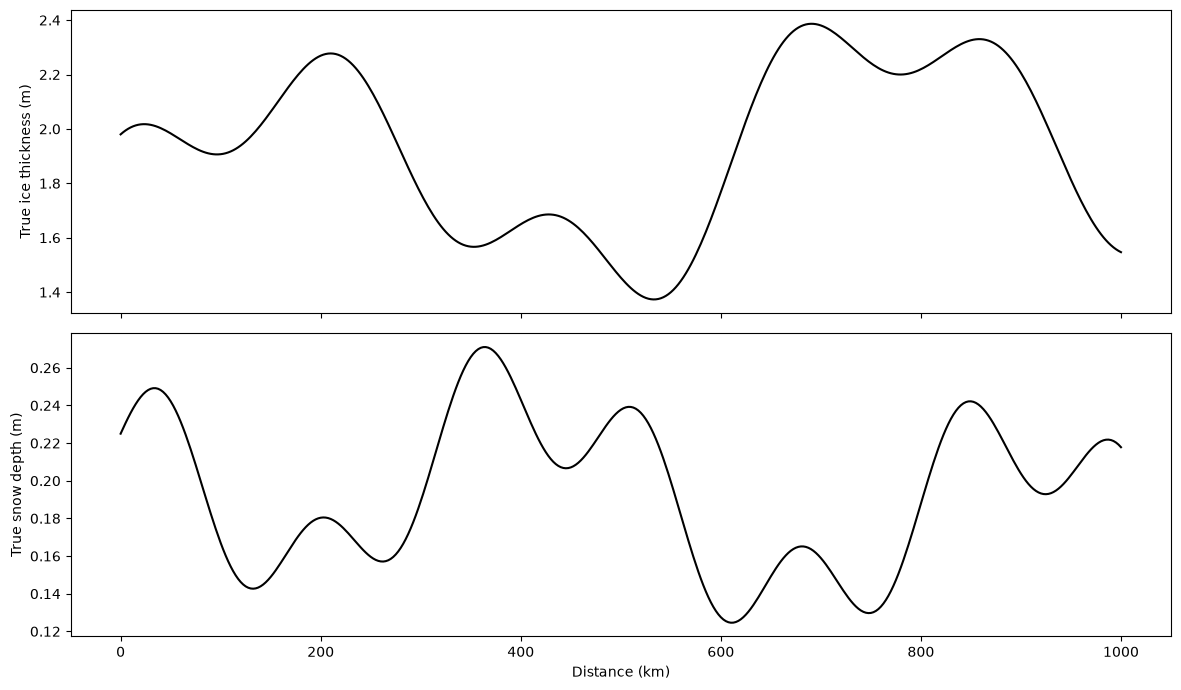

In [2]:
base = pred[(pred['scenario']=='noise_nominal') & (pred['replicate']==0)]
fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axs[0].plot(base['x_km'], base['true_Hi_m'], color='black')
axs[0].set_ylabel('True ice thickness (m)')
axs[1].plot(base['x_km'], base['true_Hs_m'], color='black')
axs[1].set_ylabel('True snow depth (m)')
axs[1].set_xlabel('Distance (km)')
plt.tight_layout()


## Mean recovery error across four replicates


In [3]:
scenario_order = [
    'noise_low', 'noise_nominal', 'noise_high',
    'density_sparse', 'density_dense',
    'penetration_radar_partial', 'penetration_laser_partial', 'penetration_combined'
]
for scenario in scenario_order:
    print(scenario)
    for method in ['Point + linear', 'Positive GP']:
        row = metrics[(metrics['scenario']==scenario) & (metrics['method']==method)]
        hi = row['RMSE_m'][row['latent']=='Hi']
        hs = row['RMSE_m'][row['latent']=='Hs']
        print(f'  {method:14s} Hi={hi.mean():.4f}±{hi.std(ddof=1):.4f} m  Hs={hs.mean():.4f}±{hs.std(ddof=1):.4f} m')


noise_low
  Point + linear Hi=0.0690±0.0062 m  Hs=0.0121±0.0017 m
  Positive GP    Hi=0.0397±0.0090 m  Hs=0.0098±0.0021 m
noise_nominal
  Point + linear Hi=0.1502±0.0114 m  Hs=0.0208±0.0021 m
  Positive GP    Hi=0.0935±0.0178 m  Hs=0.0151±0.0023 m
noise_high
  Point + linear Hi=0.2697±0.0342 m  Hs=0.0471±0.0052 m
  Positive GP    Hi=0.1375±0.0112 m  Hs=0.0273±0.0028 m
density_sparse
  Point + linear Hi=0.1419±0.0305 m  Hs=0.0288±0.0052 m
  Positive GP    Hi=0.1352±0.0416 m  Hs=0.0255±0.0049 m
density_dense
  Point + linear Hi=0.1435±0.0132 m  Hs=0.0217±0.0017 m
  Positive GP    Hi=0.0608±0.0057 m  Hs=0.0120±0.0007 m
penetration_radar_partial
  Point + linear Hi=0.2989±0.0353 m  Hs=0.0469±0.0022 m
  Positive GP    Hi=0.2724±0.0370 m  Hs=0.0422±0.0032 m
penetration_laser_partial
  Point + linear Hi=0.1790±0.0360 m  Hs=0.0315±0.0041 m
  Positive GP    Hi=0.1398±0.0327 m  Hs=0.0233±0.0031 m
penetration_combined
  Point + linear Hi=0.2131±0.0184 m  Hs=0.0671±0.0017 m
  Positive GP    Hi=0.1

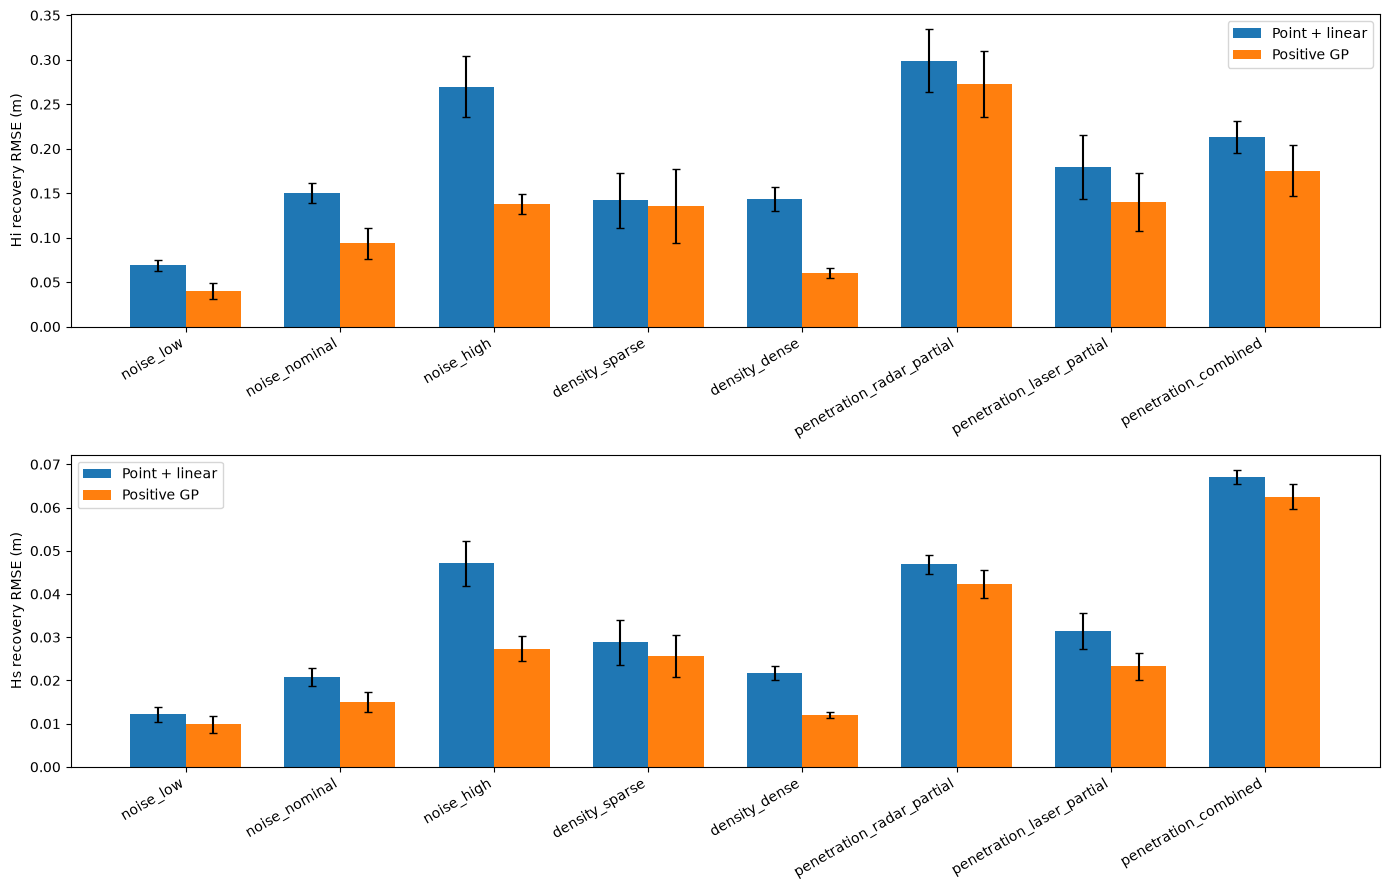

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(14, 9))
x = np.arange(len(scenario_order))
width = .36
for ax, latent in zip(axs, ['Hi', 'Hs']):
    for offset, method in [(-width/2, 'Point + linear'), (width/2, 'Positive GP')]:
        means=[]; stds=[]
        for scenario in scenario_order:
            values=metrics['RMSE_m'][(metrics['scenario']==scenario)&(metrics['method']==method)&(metrics['latent']==latent)]
            means.append(values.mean()); stds.append(values.std(ddof=1))
        ax.bar(x+offset, means, width, yerr=stds, capsize=3, label=method)
    ax.set_xticks(x, scenario_order, rotation=30, ha='right')
    ax.set_ylabel(f'{latent} recovery RMSE (m)')
    ax.legend()
plt.tight_layout()


## Representative recovered fields


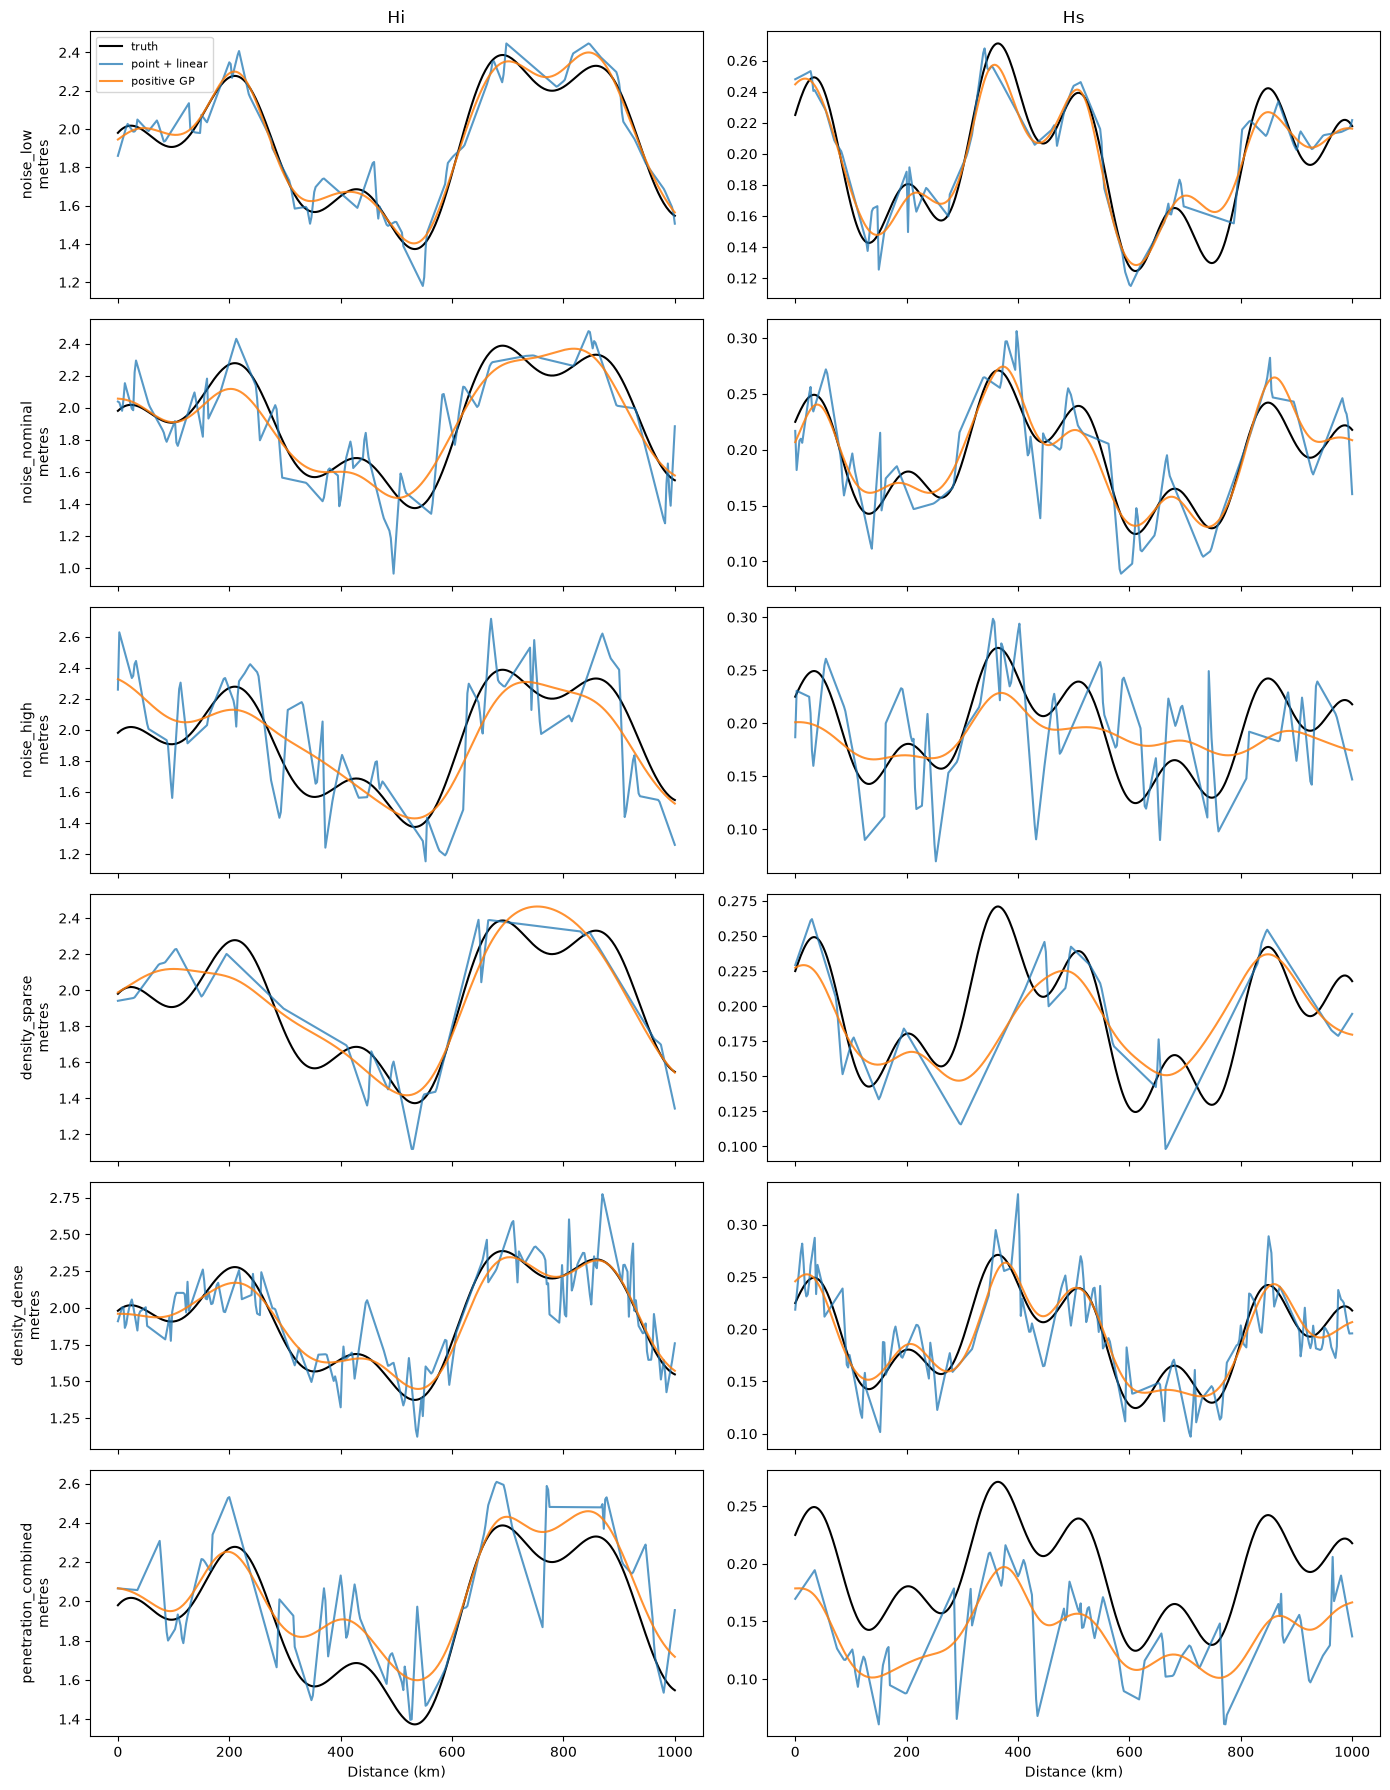

In [5]:
representative = ['noise_low','noise_nominal','noise_high','density_sparse','density_dense','penetration_combined']
fig, axs = plt.subplots(len(representative), 2, figsize=(14, 18), sharex=True)
for row, scenario in enumerate(representative):
    d = pred[(pred['scenario']==scenario)&(pred['replicate']==0)]
    for col, latent in enumerate(['Hi','Hs']):
        ax=axs[row,col]
        ax.plot(d['x_km'], d[f'true_{latent}_m'], color='black', label='truth')
        ax.plot(d['x_km'], d[f'point_{latent}_m'], alpha=.75, label='point + linear')
        ax.plot(d['x_km'], d[f'positive_gp_{latent}_m'], alpha=.85, label='positive GP')
        if col==0: ax.set_ylabel(scenario+'\nmetres')
        if row==0: ax.set_title(latent)
        if row==0 and col==0: ax.legend(fontsize=8)
axs[-1,0].set_xlabel('Distance (km)'); axs[-1,1].set_xlabel('Distance (km)')
plt.tight_layout()


## Factor-specific interpretation


In [6]:
def mean_rmse(scenario, latent, method='Positive GP'):
    values=metrics['RMSE_m'][(metrics['scenario']==scenario)&(metrics['method']==method)&(metrics['latent']==latent)]
    return float(values.mean())

print('Noise degradation, low -> high:')
for latent in ['Hi','Hs']:
    print(latent, mean_rmse('noise_low',latent), '->', mean_rmse('noise_high',latent))
print('Density improvement, 25 -> 120 observations:')
for latent in ['Hi','Hs']:
    print(latent, mean_rmse('density_sparse',latent), '->', mean_rmse('density_dense',latent))
print('Penetration mismatch:')
for scenario in ['penetration_radar_partial','penetration_laser_partial','penetration_combined']:
    print(scenario, {latent: mean_rmse(scenario,latent) for latent in ['Hi','Hs']})
print('Total negative positive-GP predictions:', int(metrics['negative_dense_predictions'][metrics['method']=='Positive GP'].sum()))


Noise degradation, low -> high:
Hi 0.0397467403000189 -> 0.137450720962993
Hs 0.0098119245136582 -> 0.02732527980002316
Density improvement, 25 -> 120 observations:
Hi 0.13518823454540274 -> 0.06076868534359966
Hs 0.025542184660614045 -> 0.012005712722532015
Penetration mismatch:
penetration_radar_partial {'Hi': 0.2723527305465384, 'Hs': 0.042242009897350996}
penetration_laser_partial {'Hi': 0.13978877662476583, 'Hs': 0.023263926477906073}
penetration_combined {'Hi': 0.17520222657220672, 'Hs': 0.06253625201940158}
Total negative positive-GP predictions: 0


## Evidence-based conclusions

- Under nominal conditions the positive GP recovers ice thickness with mean
  RMSE 0.094 m and snow depth with mean RMSE 0.015 m.
- Raising noise from low to high increases positive-GP RMSE from 0.040 to
  0.138 m for ice and from 0.010 to 0.027 m for snow.
- Increasing density from 25 to 120 observations reduces ice RMSE from 0.135
  to 0.061 m and snow RMSE from 0.026 to 0.012 m.
- Penetration misspecification is more damaging than nominal random noise.
  Partial radar penetration produces 0.272 m ice RMSE; combined radar/laser
  mismatch produces 0.063 m snow RMSE.
- The positive GP beats pointwise inversion plus linear interpolation in every
  tested scenario and produces no negative latent estimates.
- The non-additive combined-penetration response shows that coefficient errors
  can partially cancel for one latent while worsening the other. Penetration
  parameters therefore cannot be interpreted through one-sensor sensitivity
  alone.

These experiments establish recovery capability when truth is known, while
also showing that uncertainty in penetration physics can dominate measurement
noise. This supports treating $lpha_{CS2}$ and $lpha_{IS2}$ as sensitivity
parameters or uncertain quantities in the dissertation rather than fixed,
perfectly known constants.
